We test the M&uuml;ller-Brown potential given by 
\begin{aligned}
E_{MB}(x,y)=\sum_{i=1}^{4}A_{i}\exp [a_{i}(x-\bar{x}_{i})^{2}+b_{i}(x-\bar{x}_{i})(y-\bar{y}_{i})+c_{i}(y-\bar{y}_{i})^{2}].
\end{aligned}
We set the parameters as
\begin{aligned}
A=[-200,-100,-170,15], a=[-1,-1,-6.5,0.7], b=[0,0,11,0.6], c=[-10,-10,-6.5,0.7], \bar{x}=[1,0,-0.5,-1], \bar{y}=[0,0.5,1.5,1].
\end{aligned}

First, we add the path of the `saddlescape-1.0` directory to the system path.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'saddlescape-1.0')))


Then, we import the main class.

In [2]:
from saddlescape import Landscape
import numpy as np

# import packages needed

We define the energy function.

In [3]:
MBP_energyfunc='-200*exp(-1*(x1-1)**2-10*(x2-0)**2)-100*exp(-1*(x1-0)**2-10*(x2-0.5)**2)-170*exp(-6.5*(x1+0.5)**2' \
'+11*(x1+0.5)*(x2-1.5)-6.5*(x2-1.5)**2)+15*exp(0.7*(x1+1)**2+0.6*(x1+1)*(x2-1)+0.7*(x2-1)**2)'

We initialize the solver and run it.

In [4]:
# parameter initialization
x0 = np.array([0.15, 0.25]) # initial point
dt = 1e-4 # time step
k = 1 # the maximum index of saddle point
acceme = 'none' # use the heavy ball to accelerate
maxiter = 5000 # max iter

As an example of user-defined temporal discretization, we apply a second-order explicit Adams update to the $x$-equation while retaining the default eigenspace update.

In [5]:
def adams_bashforth_2nd_for_x(instance, xlist, vlist, glist, dt, j):
    import numpy as np
    import copy

    x_n = copy.deepcopy(xlist[-1])
    g_n = copy.deepcopy(glist[-1])
    if vlist is not None:
      # ================== index-k (k>=1) ==================
        v_n = copy.deepcopy(vlist[-1])
        phi_n = g_n - 2.0 * np.matmul(v_n, np.matmul(v_n.T, g_n))
        if j == 1 or len(glist) < 2:
            dx = dt * phi_n
        else:
            v_prev = copy.deepcopy(vlist[-2])
            g_prev = copy.deepcopy(glist[-2])
            phi_prev = g_prev - 2.0 * np.matmul(v_prev, np.matmul(v_prev.T, g_prev))
            dx = dt * (1.5 * phi_n - 0.5 * phi_prev)
        x_next = x_n - dx
        v_next, whetherkindex = instance.EigVecMethod(x_next, v_n)
        return x_next, v_next, whetherkindex
    else:
        # ================== index-0 ==================
        if j == 1 or len(glist) < 2:
            dx = dt * g_n
        else:
            # Second-order explicit Adams-Bashforth scheme for x
            g_prev = glist[-2]
            dx = dt * (1.5 * g_n - 0.5 * g_prev)

        x_next = x_n - dx

        return x_next

In [6]:
MyLandscape = Landscape(MaxIndex=k, AutoDiff=True, ExactHessian=True, EnergyFunction=MBP_energyfunc, 
						InitialPoint=x0, TimeStep=dt, Acceleration=acceme, BBStep=False,
						EigenStepSize=1e-7, MaxIter=maxiter,EigenMethod='euler', Verbose=True, ReportInterval=100,
            CustomTD=adams_bashforth_2nd_for_x, CustomTD_Step=2)
# Instantiation
MyLandscape.Run()
# Calculate

HiSD Solver Configuration:
------------------------------
[HiSD] Current parameters (initialized):
[Config Sync] `Dim` parameter auto-adjusted to 2 based on `InitialPoint` dimensionality.
Parameter `NumericalGrad` not specified - using default value False.
Parameter `Momentum` not specified - using default value 0.0.
Parameter `DimerLength` not specified - using default value 1e-05.
Parameter `Tolerance` not specified - using default value 1e-06.
Parameter `NesterovChoice` not specified - using default value 1.
Parameter `SearchArea` not specified - using default value 1000.0.
Parameter `NesterovRestart` not specified - using default value None.
Parameter `EigenMaxIter` not specified - using default value 10.
Parameter `HessianDimerLength` not specified - using default value 1e-05.
Parameter `PrecisionTol` not specified - using default value 1e-05.
Parameter `EigvecUnified` not specified - using default value False.
Parameter 'GradientSystem' not provided. Enabling automatic symmetry d

We draw the search trajectory.

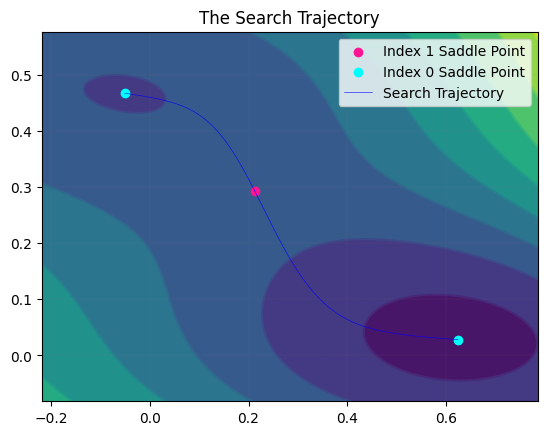

In [7]:
MyLandscape.DrawTrajectory(ContourGridNum=100, ContourGridOut=25, DetailedTraj=True)
# Draw the search path.

We can also draw the solution landscape.

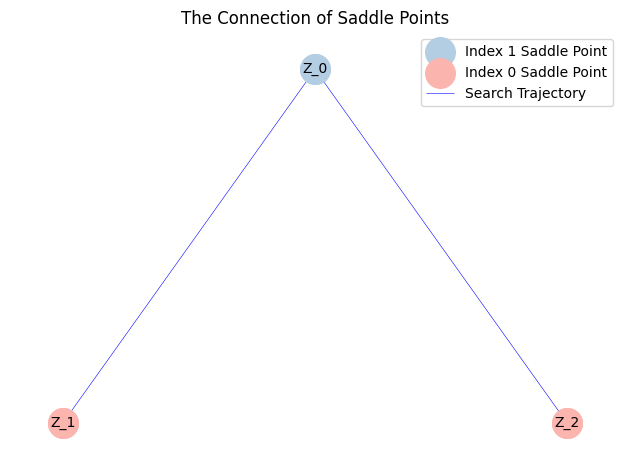

In [8]:
MyLandscape.DrawConnection()

However, this solution landscape is not completed. We restart the algorithm from ID-1 saddle point.

In [9]:
MyLandscape.RestartFromSaddle(1, np.array([[-0.01],[0]]), 1)
# Calculate



From initial point search index-1:
------------------------------


Iteration: 100|| Norm of gradient: 19.312756
Iteration: 200|| Norm of gradient: 73.350020
Iteration: 300|| Norm of gradient: 5.393141
Iteration: 400|| Norm of gradient: 0.296593
Iteration: 500|| Norm of gradient: 0.007024
Iteration: 600|| Norm of gradient: 0.000128
Iteration: 700|| Norm of gradient: 0.000001
Non-degenerate saddle point identified: Morse index =1 (number of negative eigenvalues).


From saddle point (index-1, ID-3) search index-0:
------------------------------


Iteration: 100|| Norm of gradient: 173.689102
Iteration: 200|| Norm of gradient: 11.176428
Iteration: 300|| Norm of gradient: 0.189779
Iteration: 400|| Norm of gradient: 0.003139
Iteration: 500|| Norm of gradient: 0.000052
Non-degenerate saddle point identified: Morse index =0 (number of negative eigenvalues).


From saddle point (index-1, ID-3) search index-0:
------------------------------


Iteration: 100|| Norm of gradient: 59.383010
Iter

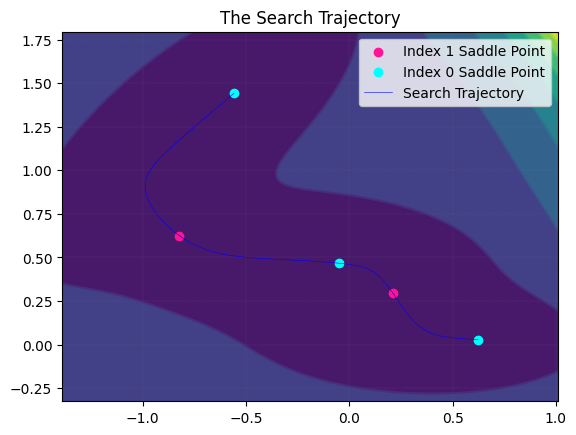

In [10]:
MyLandscape.DrawTrajectory(ContourGridNum=100, ContourGridOut=25, DetailedTraj=True)
# Draw the search path. But because of the large dimension, we cannot draw the picture.

From the output, we can find a complete solution landscape.

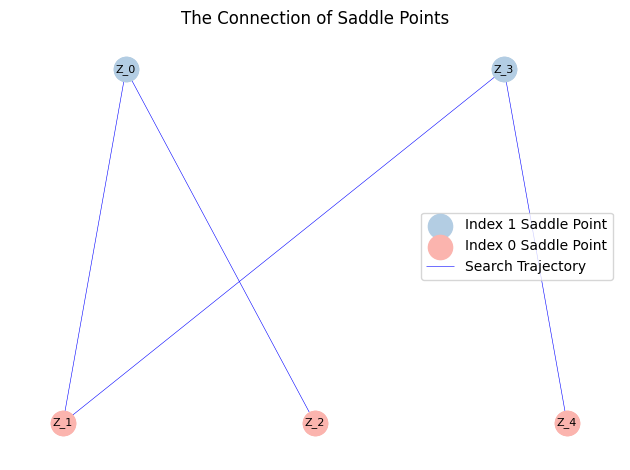

In [11]:
MyLandscape.DrawConnection()
MyLandscape.Save('output/Ex_MBP','pickle')
# Save the data